# 02. Match Prediction Dataset Construction

## 1. Research Goal

Цель этапа состоит в формировании единого модельного датасета для прогнозирования исхода матча NBA на уровне «команда — матч». Датасет объединяет историческую форму команды, характеристики состава, финансовый контекст и новостной фон.

Итоговый набор предназначен для последующего применения в baseline-моделях, deep learning архитектурах и прикладном сервисе прогнозирования.

## 2. Environment Setup

Раздел задает вычислительную среду, параметры отображения и директории хранения артефактов. Стандартизированная структура выходных файлов обеспечивает воспроизводимость конвейера подготовки данных.

In [ ]:
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 40)
sns.set_style("whitegrid")

In [ ]:
# Пути проекта
for p in [
    Path('data/processed'),
    Path('data/reports'),
    Path('artifacts/eda/figures'),
    Path('artifacts/eda/tables'),
    Path('docs'),
]:
    p.mkdir(parents=True, exist_ok=True)

## 3. Data Loading and Initial Validation

Раздел выполняет загрузку всех исходных таблиц и первичную проверку полноты. Это необходимо для фиксации объема данных, структуры полей и временного покрытия перед объединением источников.

In [ ]:
from pathlib import Path

BOX_SCORES_PATH = Path("NBA Player Box Score Stats(1950 - 2022).csv")
PLAYER_STATS_PATH = Path("NBA Player Stats(1950 - 2022).csv")
SALARIES_PATH = Path("NBA Salaries(1990-2023).csv")
PAYROLL_PATH = Path("NBA Payroll(1990-2023).csv")
NEWS_DAILY_PATH = Path("nba_news_daily_features.csv")

paths = {
    "box_scores_path": BOX_SCORES_PATH,
    "player_stats_path": PLAYER_STATS_PATH,
    "salaries_path": SALARIES_PATH,
    "payroll_path": PAYROLL_PATH,
    "news_daily_path": NEWS_DAILY_PATH,
}

for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {name} -> {path}")

box_scores_path = BOX_SCORES_PATH
player_stats_path = PLAYER_STATS_PATH
salaries_path = SALARIES_PATH
payroll_path = PAYROLL_PATH
news_daily_path = NEWS_DAILY_PATH

print("Все файлы успешно найдены:")
for name, path in paths.items():
    print(f"{name}: {path}")

Все файлы успешно найдены:
box_scores_path: NBA Player Box Score Stats(1950 - 2022).csv
player_stats_path: NBA Player Stats(1950 - 2022).csv
salaries_path: NBA Salaries(1990-2023).csv
payroll_path: NBA Payroll(1990-2023).csv
news_daily_path: nba_news_daily_features.csv


In [ ]:
# Загрузка данных
box_scores = pd.read_csv(box_scores_path)
player_stats = pd.read_csv(player_stats_path)
salaries = pd.read_csv(salaries_path)
payroll = pd.read_csv(payroll_path)
news_daily_features = pd.read_csv(news_daily_path)

datasets = {
    'box_scores': box_scores,
    'player_stats': player_stats,
    'salaries': salaries,
    'payroll': payroll,
    'news_daily_features': news_daily_features,
}

In [ ]:
# Нормализация колонок
def quick_summary(name: str, df: pd.DataFrame):
    print('=' * 100)
    print(name)
    print('shape:', df.shape)
    print('columns:', list(df.columns))
    display(df.head(3))
    miss_share = float(df.isna().mean().mean())
    print('missing_share_global:', round(miss_share, 6))

for n, d in datasets.items():
    quick_summary(n, d)

box_scores
shape: (1309778, 29)
columns: ['Unnamed: 0', 'Season', 'Game_ID', 'PLAYER_NAME', 'Team', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE']


,Unnamed: 0,Season,Game_ID,PLAYER_NAME,Team,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,531380,1946,24600034,Adolph Hoefer,HUS,"NOV 19, 1946",HUS vs. CLR,L,0,0,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0,NaN,0
1,531378,1946,24600045,Adolph Hoefer,HUS,"NOV 23, 1946",HUS @ WAS,L,0,3,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,0
2,531379,1946,24600042,Adolph Hoefer,HUS,"NOV 22, 1946",HUS vs. BOS,W,0,1,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,0


missing_share_global: 0.100243
player_stats
shape: (28237, 32)
columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Season', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']


,Unnamed: 0.1,Unnamed: 0,Season,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,0,1950,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,144.0,516.0,0.279,NaN,NaN,NaN,144.0,516.0,0.279,0.279,170.0,241.0,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1,1950,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,102.0,274.0,0.372,NaN,NaN,NaN,102.0,274.0,0.372,0.372,75.0,106.0,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,2,1950,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,174.0,499.0,0.349,NaN,NaN,NaN,174.0,499.0,0.349,0.349,90.0,129.0,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0


missing_share_global: 0.055929
salaries
shape: (15857, 5)
columns: ['Unnamed: 0', 'playerName', 'seasonStartYear', 'salary', 'inflationAdjSalary']


...

missing_share_global: 0.0
payroll
shape: (966, 5)
columns: ['Unnamed: 0', 'team', 'seasonStartYear', 'payroll', 'inflationAdjPayroll']


,Unnamed: 0,team,seasonStartYear,payroll,inflationAdjPayroll
0,0,Cleveland,1990,"$14,403,000","$32,854,246"
1,1,New York,1990,"$13,290,000","$30,315,416"
2,2,Detroit,1990,"$12,910,000","$29,448,608"


missing_share_global: 0.0
news_daily_features
shape: (7038, 110)
columns: ['news_date', 'team', 'news_count', 'avg_gdelt_tone', 'min_gdelt_tone', 'max_gdelt_tone', 'avg_sentiment_score_kw', 'sum_positive_hits', 'sum_negative_hits', 'positive_news_count', 'negative_news_count', 'neutral_news_count', 'injury_news_count', 'trade_news_count', 'win_news_count', 'loss_news_count', 'playoff_news_count', 'roster_news_count', 'avg_title_len', 'avg_title_word_count', 'news_count_lag1', 'news_count_rollmean_3', 'news_count_rollmean_7', 'news_count_rollsum_3', 'news_count_rollsum_7', 'avg_gdelt_tone_lag1', 'avg_gdelt_tone_rollmean_3', 'avg_gdelt_tone_rollmean_7', 'avg_gdelt_tone_rollsum_3', 'avg_gdelt_tone_rollsum_7', 'min_gdelt_tone_lag1', 'min_gdelt_tone_rollmean_3', 'min_gdelt_tone_rollmean_7', 'min_gdelt_tone_rollsum_3', 'min_gdelt_tone_rollsum_7', 'max_gdelt_tone_lag1', 'max_gdelt_tone_rollmean_3', 'max_gdelt_tone_rollmean_7', 'max_gdelt_tone_rollsum_3', 'max_gdelt_tone_rollsum_7', 'avg_senti

,news_date,team,news_count,avg_gdelt_tone,min_gdelt_tone,max_gdelt_tone,avg_sentiment_score_kw,sum_positive_hits,sum_negative_hits,positive_news_count,negative_news_count,neutral_news_count,injury_news_count,trade_news_count,win_news_count,loss_news_count,playoff_news_count,roster_news_count,avg_title_len,avg_title_word_count,news_count_lag1,news_count_rollmean_3,news_count_rollmean_7,news_count_rollsum_3,news_count_rollsum_7,avg_gdelt_tone_lag1,avg_gdelt_tone_rollmean_3,avg_gdelt_tone_rollmean_7,avg_gdelt_tone_rollsum_3,avg_gdelt_tone_rollsum_7,min_gdelt_tone_lag1,min_gdelt_tone_rollmean_3,min_gdelt_tone_rollmean_7,min_gdelt_tone_rollsum_3,min_gdelt_tone_rollsum_7,max_gdelt_tone_lag1,max_gdelt_tone_rollmean_3,max_gdelt_tone_rollmean_7,max_gdelt_tone_rollsum_3,max_gdelt_tone_rollsum_7,avg_sentiment_score_kw_lag1,avg_sentiment_score_kw_rollmean_3,avg_sentiment_score_kw_rollmean_7,avg_sentiment_score_kw_rollsum_3,avg_sentiment_score_kw_rollsum_7,sum_positive_hits_lag1,sum_positive_hits_rollmean_3,sum_positive_hits_rollmean_7,sum_positive_hits_rollsum_3,sum_positive_hits_rollsum_7,sum_negative_hits_lag1,sum_negative_hits_rollmean_3,sum_negative_hits_rollmean_7,sum_negative_hits_rollsum_3,sum_negative_hits_rollsum_7,positive_news_count_lag1,positive_news_count_rollmean_3,positive_news_count_rollmean_7,positive_news_count_rollsum_3,positive_news_count_rollsum_7,negative_news_count_lag1,negative_news_count_rollmean_3,negative_news_count_rollmean_7,negative_news_count_rollsum_3,negative_news_count_rollsum_7,neutral_news_count_lag1,neutral_news_count_rollmean_3,neutral_news_count_rollmean_7,neutral_news_count_rollsum_3,neutral_news_count_rollsum_7,injury_news_count_lag1,injury_news_count_rollmean_3,injury_news_count_rollmean_7,injury_news_count_rollsum_3,injury_news_count_rollsum_7,trade_news_count_lag1,trade_news_count_rollmean_3,trade_news_count_rollmean_7,trade_news_count_rollsum_3,trade_news_count_rollsum_7,win_news_count_lag1,win_news_count_rollmean_3,win_news_count_rollmean_7,win_news_count_rollsum_3,win_news_count_rollsum_7,loss_news_count_lag1,loss_news_count_rollmean_3,loss_news_count_rollmean_7,loss_news_count_rollsum_3,loss_news_count_rollsum_7,playoff_news_count_lag1,playoff_news_count_rollmean_3,playoff_news_count_rollmean_7,playoff_news_count_rollsum_3,playoff_news_count_rollsum_7,roster_news_count_lag1,roster_news_count_rollmean_3,roster_news_count_rollmean_7,roster_news_count_rollsum_3,roster_news_count_rollsum_7,avg_title_len_lag1,avg_title_len_rollmean_3,avg_title_len_rollmean_7,avg_title_len_rollsum_3,avg_title_len_rollsum_7,avg_title_word_count_lag1,avg_title_word_count_rollmean_3,avg_title_word_count_rollmean_7,avg_title_word_count_rollsum_3,avg_title_word_count_rollsum_7
0,2020-01-04,ATL,3,-0.063511,-1.279318,1.880342,0.0,0,0,0,0,3,0,3,0,0,0,0,71.666667,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-05,ATL,1,-2.260870,-2.260870,-2.260870,0.0,0,0,0,0,1,0,0,0,0,0,0,47.000000,8.0,3.0,3.0,3.0,3.0,3.0,-0.063511,-0.063511,-0.063511,-0.063511,-0.063511,-1.279318,-1.279318,-1.279318,-1.279318,-1.279318,1.880342,1.880342,1.880342,1.880342,1.880342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71.666667,71.666667,71.666667,71.666667,71.666667,12.0,12.0,12.0,12.0,12.0
2,2020-01-06,ATL,1,-1.426025,-1.426025,-1.426025,1.0,1,0,1,0,0,0,0,1,0,0,0,53.000000,9.0,1.0,2.0,2.0,4.0,4.0,-2.260870,-1.162190,-1.162190,-2.324380,-2.324380,-2.260870,-1.770094,-1.770094,-3.540187,-3.540187,-2.260870,-0.190264,-0.190264,-0.380528

missing_share_global: 0.003488


## 4. Dataset Granularity and Merge Strategy

Исходные источники представлены на различных уровнях детализации: `box_scores` — игрок × матч, `player_stats` и `salaries` — игрок × сезон, `payroll` — команда × сезон, `news_daily_features` — команда × дата. Целевой уровень итоговой таблицы определяется как «команда × матч».

Для обеспечения корректной интеграции данные приводятся к совместимому уровню: матчевые данные агрегируются до команды в матче, сезонные данные состава и финансов агрегируются до команды в сезоне, новостные признаки трансформируются в lag/rolling-представления по команде и дате.

## 5. Column Standardization

Раздел выполняет единообразную нормализацию имен полей и ключей объединения. Стандартизация снижает риск ошибок merge и формирует устойчивую схему конвейера.

In [ ]:
# Нормализация колонок
for key in datasets:
    datasets[key] = datasets[key].loc[:, ~datasets[key].columns.str.startswith('Unnamed')].copy()

box_scores = datasets['box_scores'].rename(columns={
    'Season': 'season', 'Game_ID': 'game_id', 'PLAYER_NAME': 'player',
    'Team': 'team', 'GAME_DATE': 'game_date', 'MATCHUP': 'matchup',
    'WL': 'result', 'MIN': 'minutes'
})

player_stats = datasets['player_stats'].rename(columns={
    'Season': 'season', 'Player': 'player', 'Tm': 'team', 'Pos': 'position', 'Age': 'age'
})

salaries = datasets['salaries'].rename(columns={
    'playerName': 'player', 'seasonStartYear': 'season'
})

payroll = datasets['payroll'].rename(columns={
    'seasonStartYear': 'season'
})

news_daily_features = datasets['news_daily_features'].copy()


def normalize_team_text(s: pd.Series) -> pd.Series:
    return s.astype(str).str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)

for df, col in [(box_scores, 'team'), (player_stats, 'team'), (news_daily_features, 'team')]:
    if col in df.columns:
        df[col] = normalize_team_text(df[col])

for df in [box_scores, player_stats, salaries, payroll]:
    if 'player' in df.columns:
        df['player'] = df['player'].astype(str).str.strip()
    if 'season' in df.columns:
        df['season'] = pd.to_numeric(df['season'], errors='coerce')

# Корректный парсинг даты
box_scores['game_date'] = pd.to_datetime(box_scores['game_date'], errors='coerce')
if 'news_date' in news_daily_features.columns:
    news_daily_features['news_date'] = pd.to_datetime(news_daily_features['news_date'], errors='coerce')

## 6. Team and Match Extraction from Box Scores

Раздел формирует базовую таблицу наблюдений «игрок — матч», из которой извлекаются параметры матчевого контекста и целевая переменная. Корректность opponent и home/away проверяется до этапа агрегации.

In [ ]:
# Агрегация командной статистики
player_game = box_scores.copy()

for c in ['PTS','AST','REB','STL','BLK','TOV','PF','FGM','FGA','FG3M','FG3A','FTM','FTA','PLUS_MINUS','minutes']:
    if c in player_game.columns:
        player_game[c] = pd.to_numeric(player_game[c], errors='coerce')

player_game['opponent'] = player_game['matchup'].astype(str).str.extract(r'(?:vs\.|@)\s*([A-Z]{2,3})', expand=False)
player_game['is_home'] = player_game['matchup'].astype(str).str.contains('vs\.', regex=True, na=False).astype(int)
player_game['win_flag'] = (player_game['result'] == 'W').astype(int)
player_game['target_win'] = player_game['win_flag']

print('rows player_game:', len(player_game))
print('unique games:', player_game['game_id'].nunique())
print('unique teams:', player_game['team'].nunique())
print('bad game_date share:', round(player_game['game_date'].isna().mean(), 6))
print('opponent missing share:', round(player_game['opponent'].isna().mean(), 6))
print('home share:', round(player_game['is_home'].mean(), 6))

display(player_game[['game_id','game_date','team','opponent','is_home','result','target_win']].head(10))

rows player_game: 1309778
unique games: 64805
unique teams: 75
bad game_date share: 0.0
opponent missing share: 0.0
home share: 0.500237


,game_id,game_date,team,opponent,is_home,result,target_win
0,24600034,1946-11-19,HUS,CLR,1,L,0
1,24600045,1946-11-23,HUS,WAS,0,L,0
2,24600042,1946-11-22,HUS,BOS,1,W,1
3,24600051,1946-11-26,HUS,WAS,1,L,0
4,24600061,1946-11-29,HUS,CLR,1,L,0
5,24600062,1946-11-30,HUS,PRO,0,L,0
6,24600073,1946-12-05,HUS,CHS,0,W,1
7,24600080,1946-12-07,HUS,PRO,0,W,1
8,24600085,1946-12-10,HUS,PHW,1,L,0
9,24600093,1946-12-13,HUS,PIT,1,L,0


Ключевая структура наблюдений сформирована, целевая переменная определена напрямую из результата матча. Для дальнейшего моделирования используются только признаки, доступные до начала игры.

## 7. Team-Game Aggregation

Раздел агрегирует данные игроков до уровня «команда — матч». Текущие матчевые значения используются только как промежуточная база для построения исторических rolling-признаков.

In [ ]:
# Агрегация командной статистики
team_game = (
    player_game
    .groupby(['game_id','game_date','season','team'], as_index=False)
    .agg({
        'opponent':'first',
        'is_home':'max',
        'win_flag':'max',
        'target_win':'max',
        'PTS':'sum','AST':'sum','REB':'sum','STL':'sum','BLK':'sum','TOV':'sum','PF':'sum',
        'FGM':'sum','FGA':'sum','FG3M':'sum','FG3A':'sum','FTM':'sum','FTA':'sum','minutes':'sum'
    })
)

team_game = team_game.rename(columns={
    'PTS':'team_PTS','AST':'team_AST','REB':'team_REB','STL':'team_STL','BLK':'team_BLK',
    'TOV':'team_TOV','PF':'team_PF','FGM':'team_FGM','FGA':'team_FGA','FG3M':'team_FG3M',
    'FG3A':'team_FG3A','FTM':'team_FTM','FTA':'team_FTA','minutes':'team_minutes'
})

safe_div = lambda a, b: np.where(pd.to_numeric(b, errors='coerce') > 0, pd.to_numeric(a, errors='coerce') / pd.to_numeric(b, errors='coerce'), np.nan)

team_game['team_fg_pct'] = safe_div(team_game['team_FGM'], team_game['team_FGA'])
team_game['team_fg3_pct'] = safe_div(team_game['team_FG3M'], team_game['team_FG3A'])
team_game['team_ft_pct'] = safe_div(team_game['team_FTM'], team_game['team_FTA'])
team_game['possessions_proxy'] = team_game['team_FGA'] + 0.44 * team_game['team_FTA'] + team_game['team_TOV']
team_game['offensive_activity_proxy'] = team_game['team_FGA'] + 0.44 * team_game['team_FTA']
team_game['team_efficiency_proxy'] = (
    team_game['team_PTS'] + team_game['team_REB'] + team_game['team_AST'] + team_game['team_STL'] + team_game['team_BLK']
    - team_game['team_TOV'] - team_game['team_PF']
)

print('team_game rows:', len(team_game))
display(team_game.head(5))

team_game rows: 129609


,game_id,game_date,season,team,opponent,is_home,win_flag,target_win,team_PTS,team_AST,team_REB,team_STL,team_BLK,team_TOV,team_PF,team_FGM,team_FGA,team_FG3M,team_FG3A,team_FTM,team_FTA,team_minutes,team_fg_pct,team_fg3_pct,team_ft_pct,possessions_proxy,offensive_activity_proxy,team_efficiency_proxy
0,20000001,2000-10-31,2000,NYK,PHI,1,0,0,72,14.0,37.0,6.0,4.0,22.0,30.0,25,70.0,3.0,11.0,19,24.0,238,0.357143,0.272727,0.791667,102.56,80.56,81.0
1,20000001,2000-10-31,2000,PHI,NYK,0,1,1,101,27.0,37.0,10.0,5.0,13.0,24.0,38,66.0,3.0,8.0,22,30.0,240,0.575758,0.375000,0.733333,92.20,79.20,143.0
2,20000002,2000-10-31,2000,CLE,NJN,0,1,1,86,16.0,52.0,5.0,8.0,19.0,27.0,32,78.0,2.0,7.0,20,32.0,240,0.410256,0.285714,0.625000,111.08,92.08,121.0
3,20000002,2000-10-31,2000,NJN,CLE,1,0,0,82,24.0,47.0,9.0,8.0,12.0,31.0,31,85.0,3.0,10.0,17,26.0,239,0.364706,0.300000,0.653846,108.44,96.44,127.0
4,20000003,2000-10-31,2000,ORL,WAS,1,1,1,97,20.0,37.0,10.0,9.0,15.0,24.0,34,79.0,6.0,16.0,23,33.0,240,0.430380,0.375000,0.696970,108.52,93.52,134.0


## 8. Rolling Team Form Features

Раздел формирует предматчевую динамику формы команды на основе прошлых игр. Все rolling-метрики рассчитываются через `shift(1)`, что исключает использование статистики текущего матча.

In [ ]:
# Формирование rolling-признаков
team_game = team_game.sort_values(['team', 'game_date'])

rolling_source_cols = {
    'team_PTS':'team_pts', 'team_AST':'team_ast', 'team_REB':'team_reb', 'team_TOV':'team_tov',
    'team_PF':'team_pf', 'team_STL':'team_stl', 'team_BLK':'team_blk',
    'team_fg_pct':'team_fg_pct', 'team_fg3_pct':'team_fg3_pct', 'team_ft_pct':'team_ft_pct',
    'win_flag':'team_win_rate', 'possessions_proxy':'team_possessions_proxy', 'team_efficiency_proxy':'team_efficiency_proxy'
}

for w in [3, 5, 10]:
    for src, pref in rolling_source_cols.items():
        team_game[f'{pref}_last{w}'] = (
            team_game.groupby('team')[src]
            .shift(1)
            .rolling(window=w, min_periods=1)
            .mean()
            .values
        )

print('Сформированы rolling-признаки:', len([c for c in team_game.columns if re.search(r'last(3|5|10)$', c)]))

Сформированы rolling-признаки: 39


Rolling-признаки отражают состояние команды непосредственно перед матчем и формируют корректный предиктивный контекст без утечки результата текущей игры.

## 9. Team-Season Composition Features

Раздел строит сезонные признаки структуры состава команды на основе индивидуальной статистики игроков. Полученные метрики описывают кадровый профиль и потенциальную игровую устойчивость команды.

In [ ]:
# Формирование признаков
ps = player_stats.copy()
for c in ['age','G','MP','PTS','AST','TRB','TOV','FGA','FTA','FG','3P']:
    if c in ps.columns:
        ps[c] = pd.to_numeric(ps[c], errors='coerce')

ps['pts_per_game'] = safe_div(ps.get('PTS'), ps.get('G'))
ps['ast_per_game'] = safe_div(ps.get('AST'), ps.get('G'))
ps['reb_per_game'] = safe_div(ps.get('TRB'), ps.get('G'))
ps['efg_pct_calc'] = safe_div(ps.get('FG') + 0.5 * ps.get('3P'), ps.get('FGA'))
ps['true_shooting_pct'] = safe_div(ps.get('PTS'), 2 * (ps.get('FGA') + 0.44 * ps.get('FTA')))
ps['ast_to_tov'] = safe_div(ps.get('AST'), ps.get('TOV'))
ps['usage_proxy'] = safe_div(ps.get('FGA') + 0.44 * ps.get('FTA') + ps.get('TOV'), ps.get('MP'))

team_season = (
    ps.groupby(['team','season'], as_index=False)
    .agg(
        roster_players_count=('player','nunique'),
        roster_avg_age=('age','mean'),
        roster_total_minutes=('MP','sum'),
        roster_total_points=('PTS','sum'),
        roster_avg_pts_per_game=('pts_per_game','mean'),
        roster_avg_ast_per_game=('ast_per_game','mean'),
        roster_avg_reb_per_game=('reb_per_game','mean'),
        roster_avg_efg_pct=('efg_pct_calc','mean'),
        roster_avg_true_shooting_pct=('true_shooting_pct','mean'),
        roster_avg_ast_to_tov=('ast_to_tov','mean'),
        roster_usage_proxy=('usage_proxy','mean')
    )
)

age_weighted = ps.groupby(['team','season']).apply(
    lambda x: np.average(x['age'].fillna(x['age'].median()) if x['age'].notna().any() else np.zeros(len(x)),
                         weights=x['MP'].fillna(0) + 1)
).reset_index(name='roster_weighted_age_by_minutes')

top_share = ps.sort_values(['team','season','PTS'], ascending=[True, True, False]).groupby(['team','season']).apply(
    lambda x: x['PTS'].iloc[0] / x['PTS'].sum() if x['PTS'].sum() and len(x) else np.nan
).reset_index(name='top_player_pts_share')

top_min_share = ps.sort_values(['team','season','MP'], ascending=[True, True, False]).groupby(['team','season']).apply(
    lambda x: x['MP'].iloc[0] / x['MP'].sum() if x['MP'].sum() and len(x) else np.nan
).reset_index(name='top_player_minutes_share')

team_season = team_season.merge(age_weighted, on=['team','season'], how='left')
team_season = team_season.merge(top_share, on=['team','season'], how='left')
team_season = team_season.merge(top_min_share, on=['team','season'], how='left')

if 'position' in ps.columns:
    pos = ps[['team','season','position']].copy()
    pos['position'] = pos['position'].astype(str).str.upper()
    pos['is_guard'] = pos['position'].str.contains('G').astype(int)
    pos['is_forward'] = pos['position'].str.contains('F').astype(int)
    pos['is_center'] = pos['position'].str.contains('C').astype(int)
    pos_agg = pos.groupby(['team','season'], as_index=False).agg(
        guards_count=('is_guard','sum'),
        forwards_count=('is_forward','sum'),
        centers_count=('is_center','sum')
    )
    pos_agg['positional_balance_proxy'] = pos_agg[['guards_count','forwards_count','centers_count']].std(axis=1)
    team_season = team_season.merge(pos_agg, on=['team','season'], how='left')

display(team_season.head(5))

,team,season,roster_players_count,roster_avg_age,roster_total_minutes,roster_total_points,roster_avg_pts_per_game,roster_avg_ast_per_game,roster_avg_reb_per_game,roster_avg_efg_pct,roster_avg_true_shooting_pct,roster_avg_ast_to_tov,roster_usage_proxy,roster_weighted_age_by_minutes,top_player_pts_share,top_player_minutes_share,guards_count,forwards_count,centers_count,positional_balance_proxy
0,AND,1950,16,27.062500,0.0,5589.0,7.403473,1.856641,NaN,NaN,0.370677,NaN,NaN,27.062500,0.203614,NaN,9,10,4,3.214550
1,ATL,1969,13,26.923077,19730.0,9123.0,10.034260,2.458889,4.847418,NaN,0.482688,NaN,NaN,27.442587,0.194015,0.148505,6,5,2,2.081666
2,ATL,1970,13,27.692308,19780.0,9646.0,10.528422,2.441800,5.015357,NaN,0.490920,NaN,NaN,27.284848,0.210554,0.165268,5,4,4,0.577350
3,ATL,1971,12,26.250000,19755.0,9348.0,10.481330,2.104800,5.074686,NaN,0.498974,NaN,NaN,27.598573,0.218122,0.158947,4,5,3,1.000000
4,ATL,1972,17,26.235294,19730.0,8982.0,8.860914,1.983826,4.372300,NaN,0.483142,NaN,NaN,26.809693,0.211423,0.161531,7,6,4,1.527525


## 10. Salary and Payroll Features

Раздел формирует финансовые признаки уровня «команда — сезон» и оценивает покрытие объединения. Финансовый контекст интерпретируется как структурный фактор состава и организационных ограничений.

In [ ]:
# Формирование признаков
sal = salaries.copy()
if 'salary' not in sal.columns:
    if 'salaryValue' in sal.columns:
        sal = sal.rename(columns={'salaryValue':'salary'})

sal['salary'] = pd.to_numeric(sal['salary'], errors='coerce') if 'salary' in sal.columns else np.nan
sal['season'] = pd.to_numeric(sal['season'], errors='coerce')
sal['player'] = sal['player'].astype(str).str.strip()

player_team_lookup = ps[['player','season','team']].drop_duplicates()
sal_team = sal.merge(player_team_lookup, on=['player','season'], how='left')

salary_coverage = float(sal_team['team'].notna().mean())

team_salary = (
    sal_team.dropna(subset=['team'])
    .groupby(['team','season'], as_index=False)
    .agg(
        team_salary_total=('salary','sum'),
        team_salary_mean=('salary','mean'),
        team_salary_median=('salary','median'),
        team_salary_max=('salary','max'),
        team_salary_std=('salary','std')
    )
)

sal_ranked = sal_team.dropna(subset=['team']).sort_values(['team','season','salary'], ascending=[True, True, False])
concentration = sal_ranked.groupby(['team','season']).apply(
    lambda x: pd.Series({
        'salary_concentration_top1': (x['salary'].head(1).sum() / x['salary'].sum()) if x['salary'].sum() else np.nan,
        'salary_concentration_top3': (x['salary'].head(3).sum() / x['salary'].sum()) if x['salary'].sum() else np.nan,
    })
).reset_index()
team_salary = team_salary.merge(concentration, on=['team','season'], how='left')

TEAM_NAME_TO_ABBR = {
    'ATLANTA HAWKS': 'ATL', 'BOSTON CELTICS': 'BOS', 'BROOKLYN NETS': 'BKN', 'NEW JERSEY NETS': 'NJN',
    'CHARLOTTE HORNETS': 'CHA', 'CHARLOTTE BOBCATS': 'CHA', 'CHICAGO BULLS': 'CHI', 'CLEVELAND CAVALIERS': 'CLE',
    'DALLAS MAVERICKS': 'DAL', 'DENVER NUGGETS': 'DEN', 'DETROIT PISTONS': 'DET', 'GOLDEN STATE WARRIORS': 'GSW',
    'HOUSTON ROCKETS': 'HOU', 'INDIANA PACERS': 'IND', 'LOS ANGELES CLIPPERS': 'LAC', 'LA CLIPPERS': 'LAC',
    'LOS ANGELES LAKERS': 'LAL', 'MEMPHIS GRIZZLIES': 'MEM', 'VANCOUVER GRIZZLIES': 'VAN', 'MIAMI HEAT': 'MIA',
    'MILWAUKEE BUCKS': 'MIL', 'MINNESOTA TIMBERWOLVES': 'MIN', 'NEW ORLEANS PELICANS': 'NOP', 'NEW ORLEANS HORNETS': 'NOH',
    'NEW YORK KNICKS': 'NYK', 'OKLAHOMA CITY THUNDER': 'OKC', 'SEATTLE SUPERSONICS': 'SEA', 'ORLANDO MAGIC': 'ORL',
    'PHILADELPHIA 76ERS': 'PHI', 'PHOENIX SUNS': 'PHX', 'PORTLAND TRAIL BLAZERS': 'POR', 'SACRAMENTO KINGS': 'SAC',
    'SAN ANTONIO SPURS': 'SAS', 'TORONTO RAPTORS': 'TOR', 'UTAH JAZZ': 'UTA', 'WASHINGTON WIZARDS': 'WAS',
    'WASHINGTON BULLETS': 'WSB'
}

pr = payroll.copy()
if 'teamName' in pr.columns:
    pr['team'] = normalize_team_text(pr['teamName']).map(TEAM_NAME_TO_ABBR).fillna(normalize_team_text(pr['teamName']))
elif 'team' in pr.columns:
    pr['team'] = normalize_team_text(pr['team'])

pr['season'] = pd.to_numeric(pr['season'], errors='coerce')
if 'payroll' in pr.columns:
    pr['payroll'] = pd.to_numeric(pr['payroll'], errors='coerce')
if 'inflationAdjPayroll' in pr.columns:
    pr['inflation_adjusted_payroll'] = pd.to_numeric(pr['inflationAdjPayroll'], errors='coerce')
elif 'inflation_adjusted_payroll' not in pr.columns:
    pr['inflation_adjusted_payroll'] = np.nan

team_financial = team_salary.merge(
    pr[['team','season','payroll','inflation_adjusted_payroll']].drop_duplicates(),
    on=['team','season'],
    how='left'
)
team_financial['salary_to_payroll_ratio'] = safe_div(team_financial['team_salary_total'], team_financial['payroll'])

team_financial['payroll_rank_in_season'] = team_financial.groupby('season')['payroll'].rank(method='average', ascending=False)
team_financial['payroll_percentile_in_season'] = team_financial.groupby('season')['payroll'].rank(pct=True)

payroll_coverage = float(team_financial['payroll'].notna().mean())

print('salary merge coverage:', round(salary_coverage, 4))
print('payroll merge coverage:', round(payroll_coverage, 4))
display(team_financial.head(5))

salary merge coverage: 0.7638
payroll merge coverage: 0.0


,team,season,team_salary_total,team_salary_mean,team_salary_median,team_salary_max,team_salary_std,salary_concentration_top1,salary_concentration_top3,payroll,inflation_adjusted_payroll,salary_to_payroll_ratio,payroll_rank_in_season,payroll_percentile_in_season
0,ATL,1990,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ATL,1991,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ATL,1992,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ATL,1993,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ATL,1994,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Финансовые признаки сформированы с обязательной оценкой покрытий объединения. Значения coverage включаются в итоговый отчет для корректной интерпретации надежности финансового блока.

## 11. News Features Preparation

Раздел строит лаговые и rolling-признаки новостного фона. Используются только значения, доступные до матча; признаки текущего дня в исходном виде не применяются.

In [ ]:
# Подключение новостных признаков
news = news_daily_features.copy()
news['team'] = normalize_team_text(news['team'])
news['news_date'] = pd.to_datetime(news['news_date'], errors='coerce')
news = news.sort_values(['team','news_date'])

news_base_cols = [
    'news_count', 'avg_gdelt_tone', 'injury_news_count', 'trade_news_count',
    'win_news_count', 'loss_news_count', 'playoff_news_count'
]
news_base_cols = [c for c in news_base_cols if c in news.columns]

for c in news_base_cols:
    news[f'{c}_lag1'] = news.groupby('team')[c].shift(1)
    news[f'{c}_rolling_mean_3'] = news.groupby('team')[c].shift(1).rolling(3, min_periods=1).mean().values
    news[f'{c}_rolling_mean_7'] = news.groupby('team')[c].shift(1).rolling(7, min_periods=1).mean().values
    news[f'{c}_rolling_sum_3'] = news.groupby('team')[c].shift(1).rolling(3, min_periods=1).sum().values
    news[f'{c}_rolling_sum_7'] = news.groupby('team')[c].shift(1).rolling(7, min_periods=1).sum().values

news_feature_cols = [c for c in news.columns if ('_lag1' in c or '_rolling_' in c)]
news_prepared = news[['team','news_date'] + news_feature_cols].copy()
news_prepared['news_date'] = news_prepared['news_date'].dt.floor('D')

display(news_prepared.head(5))

,team,news_date,news_count_lag1,avg_gdelt_tone_lag1,min_gdelt_tone_lag1,max_gdelt_tone_lag1,avg_sentiment_score_kw_lag1,sum_positive_hits_lag1,sum_negative_hits_lag1,positive_news_count_lag1,negative_news_count_lag1,neutral_news_count_lag1,injury_news_count_lag1,trade_news_count_lag1,win_news_count_lag1,loss_news_count_lag1,playoff_news_count_lag1,roster_news_count_lag1,avg_title_len_lag1,avg_title_word_count_lag1,news_count_rolling_mean_3,news_count_rolling_mean_7,news_count_rolling_sum_3,news_count_rolling_sum_7,avg_gdelt_tone_rolling_mean_3,avg_gdelt_tone_rolling_mean_7,avg_gdelt_tone_rolling_sum_3,avg_gdelt_tone_rolling_sum_7,injury_news_count_rolling_mean_3,injury_news_count_rolling_mean_7,injury_news_count_rolling_sum_3,injury_news_count_rolling_sum_7,trade_news_count_rolling_mean_3,trade_news_count_rolling_mean_7,trade_news_count_rolling_sum_3,trade_news_count_rolling_sum_7,win_news_count_rolling_mean_3,win_news_count_rolling_mean_7,win_news_count_rolling_sum_3,win_news_count_rolling_sum_7,loss_news_count_rolling_mean_3,loss_news_count_rolling_mean_7,loss_news_count_rolling_sum_3,loss_news_count_rolling_sum_7,playoff_news_count_rolling_mean_3,playoff_news_count_rolling_mean_7,playoff_news_count_rolling_sum_3,playoff_news_count_rolling_sum_7
0,ATL,2020-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ATL,2020-01-05,3.0,-0.063511,-1.279318,1.880342,0.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,71.666667,12.0,3.000000,3.000000,3.0,3.0,-0.063511,-0.063511,-0.063511,-0.063511,0.0,0.0,0.0,0.0,3.0,3.00,3.0,3.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ATL,2020-01-06,1.0,-2.260870,-2.260870,-2.260870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,47.000000,8.0,2.000000,2.000000,4.0,4.0,-1.162190,-1.162190,-2.324380,-2.324380,0.0,0.0,0.0,0.0,1.5,1.50,3.0,3.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ATL,2020-01-11,1.0,-1.426025,-1.426025,-1.426025,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,53.000000,9.0,1.666667,1.666667,5.0,5.0,-1.250135,-1.250135,-3.750405,-3.750405,0.0,0.0,0.0,0.0,1.0,1.00,3.0,3.0,0.333333,0.333333,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ATL,2020-01-13,2.0,-0.581710,-2.678571,1.515152,1.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,61.500000,10.0,1.333333,1.750000,4.0,7.0,-1.422868,-1.083029,-4.268604,-4.332115,0.0,0.0,0.0,0.0,0.0,0.75,0.0,3.0,1.000000,0.750000,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 12. Base Match Dataset

Раздел формирует базовую таблицу наблюдений уровня «команда — матч» и последовательно добавляет блоки признаков формы, состава, финансов и новостного фона.

In [ ]:
# Объединение данных
base_match = team_game[['game_id','game_date','season','team','opponent','is_home','target_win']].copy()

rolling_cols = [c for c in team_game.columns if re.search(r'last(3|5|10)$', c)]
base_match = base_match.merge(
    team_game[['game_id','team'] + rolling_cols],
    on=['game_id','team'],
    how='left'
)

base_match = base_match.merge(team_season, on=['team','season'], how='left')
base_match = base_match.merge(team_financial, on=['team','season'], how='left')

base_match['game_date_day'] = pd.to_datetime(base_match['game_date'], errors='coerce').dt.floor('D')
base_match = base_match.merge(
    news_prepared,
    left_on=['team','game_date_day'],
    right_on=['team','news_date'],
    how='left'
)
base_match = base_match.drop(columns=['news_date'])

print('base_match rows:', len(base_match))
print('base_match cols:', base_match.shape[1])

base_match rows: 129609
base_match cols: 123


## 13. Opponent Features and Difference Features

Раздел дополняет наблюдение характеристиками соперника и разностными признаками. Такой подход учитывает относительную силу сторон, что критично для задачи прогнозирования исхода матча.

In [ ]:
# Объединение признаков соперника
id_cols = ['game_id','team','opponent','game_date','season','is_home','target_win','game_date_day']
feature_base_cols = [c for c in base_match.columns if c not in id_cols]

opp_frame = base_match[['game_id','team'] + feature_base_cols].copy()
opp_frame = opp_frame.rename(columns={'team':'opponent', **{c: f'opp_{c}' for c in feature_base_cols}})

match_dataset = base_match.merge(opp_frame, on=['game_id','opponent'], how='left')

# Формирование diff-признаков
diff_candidates = [c for c in feature_base_cols if c != 'target_win']
for c in diff_candidates:
    opp_c = f'opp_{c}'
    if opp_c in match_dataset.columns:
        match_dataset[f'{c}_diff'] = match_dataset[c] - match_dataset[opp_c]

print('match_dataset rows:', len(match_dataset))
print('match_dataset cols:', match_dataset.shape[1])
display(match_dataset.head(5))

match_dataset rows: 129609
match_dataset cols: 353


,game_id,game_date,season,team,opponent,is_home,target_win,team_pts_last3,team_ast_last3,team_reb_last3,team_tov_last3,team_pf_last3,team_stl_last3,team_blk_last3,team_fg_pct_last3,team_fg3_pct_last3,team_ft_pct_last3,team_win_rate_last3,team_possessions_proxy_last3,team_efficiency_proxy_last3,team_pts_last5,team_ast_last5,team_reb_last5,team_tov_last5,team_pf_last5,team_stl_last5,team_blk_last5,team_fg_pct_last5,team_fg3_pct_last5,team_ft_pct_last5,team_win_rate_last5,team_possessions_proxy_last5,team_efficiency_proxy_last5,team_pts_last10,team_ast_last10,team_reb_last10,team_tov_last10,team_pf_last10,team_stl_last10,team_blk_last10,team_fg_pct_last10,team_fg3_pct_last10,team_ft_pct_last10,team_win_rate_last10,team_possessions_proxy_last10,team_efficiency_proxy_last10,roster_players_count,roster_avg_age,roster_total_minutes,roster_total_points,roster_avg_pts_per_game,roster_avg_ast_per_game,roster_avg_reb_per_game,roster_avg_efg_pct,roster_avg_true_shooting_pct,roster_avg_ast_to_tov,roster_usage_proxy,roster_weighted_age_by_minutes,top_player_pts_share,top_player_minutes_share,guards_count,forwards_count,centers_count,positional_balance_proxy,team_salary_total,team_salary_mean,team_salary_median,team_salary_max,team_salary_std,salary_concentration_top1,salary_concentration_top3,payroll,inflation_adjusted_payroll,salary_to_payroll_ratio,payroll_rank_in_season,payroll_percentile_in_season,game_date_day,news_count_lag1,avg_gdelt_tone_lag1,min_gdelt_tone_lag1,max_gdelt_tone_lag1,avg_sentiment_score_kw_lag1,sum_positive_hits_lag1,sum_negative_hits_lag1,positive_news_count_lag1,negative_news_count_lag1,neutral_news_count_lag1,injury_news_count_lag1,trade_news_count_lag1,win_news_count_lag1,loss_news_count_lag1,playoff_news_count_lag1,roster_news_count_lag1,avg_title_len_lag1,avg_title_word_count_lag1,news_count_rolling_mean_3,news_count_rolling_mean_7,news_count_rolling_sum_3,news_count_rolling_sum_7,avg_gdelt_tone_rolling_mean_3,...,team_reb_last5_diff,team_tov_last5_diff,team_pf_last5_diff,team_stl_last5_diff,team_blk_last5_diff,team_fg_pct_last5_diff,team_fg3_pct_last5_diff,team_ft_pct_last5_diff,team_win_rate_last5_diff,team_possessions_proxy_last5_diff,team_efficiency_proxy_last5_diff,team_pts_last10_diff,team_ast_last10_diff,team_reb_last10_diff,team_tov_last10_diff,team_pf_last10_diff,team_stl_last10_diff,team_blk_last10_diff,team_fg_pct_last10_diff,team_fg3_pct_last10_diff,team_ft_pct_last10_diff,team_win_rate_last10_diff,team_possessions_proxy_last10_diff,team_efficiency_proxy_last10_diff,roster_players_count_diff,roster_avg_age_diff,roster_total_minutes_diff,roster_total_points_diff,roster_avg_pts_per_game_diff,roster_avg_ast_per_game_diff,roster_avg_reb_per_game_diff,roster_avg_efg_pct_diff,roster_avg_true_shooting_pct_diff,roster_avg_ast_to_tov_diff,roster_usage_proxy_diff,roster_weighted_age_by_minutes_diff,top_player_pts_share_diff,top_player_minutes_share_diff,guards_count_diff,forwards_count_diff,centers_count_diff,positional_balance_proxy_diff,team_salary_total_diff,team_salary_mean_diff,team_salary_median_diff,team_salary_max_diff,team_salary_std_diff,salary_concentration_top1_diff,salary_concentration_top3_diff,payroll_diff,inflation_adjusted_payroll_diff,salary_to_payroll_ratio_diff,payroll_rank_in_season_diff,payroll_percentile_in_season_diff,news_count_lag1_diff,avg_gdelt_tone_lag1_diff,min_gdelt_tone_lag1_diff,max_gdelt_tone_lag1_diff,avg_sentiment_score_kw_lag1_diff,sum_positive_hits_lag1_diff,sum_negative_hits_lag1_diff,positive_news_count_lag1_diff,negative_news_count_lag1_diff,neutral_news_count_lag1_diff,injury_news_count_lag1_diff,trade_news_count_lag1_diff,win_news_count_lag1_diff,loss_news_count_lag1_diff,playoff_news_count_lag1_diff,roster_news_count_lag1_diff,avg_title_len_lag1_diff,avg_title_word_count_lag1_diff,news_count_rolling_mean_3_diff,news_count_rolling_mean_7_diff,news_count_rolling_sum_3_diff,news_count_rolling_sum_7_diff,avg_gdelt_tone_rolling_mean_3_diff,avg_gdelt_tone_rolling_mean_7_di

Включение `opp_` и diff-признаков повышает информативность итогового датасета за счет описания конкурентного баланса внутри конкретного матча.

## 14. Leakage Control

Раздел выполняет формальную проверку набора признаков на присутствие потенциальной утечки информации из текущего матча. Проверка является обязательной перед сохранением итогового датасета.

In [ ]:
# Контроль утечки данных
forbidden_exact = {
    'team_PTS','team_AST','team_REB','team_STL','team_BLK','team_TOV','team_FGM','team_FGA',
    'team_FG3M','team_FG3A','team_FTM','team_FTA','win_flag','target_win','result'
}

allowed_tokens = ['last','lag','rolling','roster','salary','payroll','news','diff','is_home','opp_']
non_feature_id = ['game_id','game_date','season','team','opponent','game_date_day']

feature_cols = [c for c in match_dataset.columns if c not in non_feature_id + ['target_win']]


def leakage_scan(columns: list[str]):
    suspicious = []
    for c in columns:
        cl = c.lower()
        if c in forbidden_exact:
            suspicious.append(c)
            continue
        if cl.startswith('opp_team_') and any(x in cl for x in ['pts','ast','reb','stl','blk','tov','fgm','fga','fg3m','fg3a','ftm','fta']):
            suspicious.append(c)
            continue
        if not any(tok in cl for tok in allowed_tokens):
            suspicious.append(c)
    return sorted(set(suspicious))

suspicious_cols = leakage_scan(feature_cols)

print('feature columns:', len(feature_cols))
print('suspicious leakage columns:', len(suspicious_cols))
print(suspicious_cols[:120])

status = 'dataset safe' if len(suspicious_cols) == 0 else 'requires review'
print('leakage status:', status)

feature columns: 346
suspicious leakage columns: 45
['centers_count', 'forwards_count', 'guards_count', 'opp_team_ast_last10', 'opp_team_ast_last3', 'opp_team_ast_last5', 'opp_team_blk_last10', 'opp_team_blk_last3', 'opp_team_blk_last5', 'opp_team_efficiency_proxy_last10', 'opp_team_efficiency_proxy_last3', 'opp_team_efficiency_proxy_last5', 'opp_team_fg3_pct_last10', 'opp_team_fg3_pct_last3', 'opp_team_fg3_pct_last5', 'opp_team_fg_pct_last10', 'opp_team_fg_pct_last3', 'opp_team_fg_pct_last5', 'opp_team_ft_pct_last10', 'opp_team_ft_pct_last3', 'opp_team_ft_pct_last5', 'opp_team_pf_last10', 'opp_team_pf_last3', 'opp_team_pf_last5', 'opp_team_possessions_proxy_last10', 'opp_team_possessions_proxy_last3', 'opp_team_possessions_proxy_last5', 'opp_team_pts_last10', 'opp_team_pts_last3', 'opp_team_pts_last5', 'opp_team_reb_last10', 'opp_team_reb_last3', 'opp_team_reb_last5', 'opp_team_stl_last10', 'opp_team_stl_last3', 'opp_team_stl_last5', 'opp_team_tov_last10', 'opp_team_tov_last3', 'opp_t

In [ ]:
# Контроль утечки данных
final_drop_cols = set(suspicious_cols)
final_drop_cols.update([
    c for c in match_dataset.columns if c in [
        'team_PTS','team_AST','team_REB','team_STL','team_BLK','team_TOV','team_FGM','team_FGA','team_FG3M','team_FG3A','team_FTM','team_FTA',
        'team_minutes','team_fg_pct','team_fg3_pct','team_ft_pct','possessions_proxy','offensive_activity_proxy','team_efficiency_proxy','win_flag'
    ]
])
final_drop_cols.update([c for c in match_dataset.columns if c.startswith('opp_team_') and ('last' not in c)])

match_prediction_dataset = match_dataset.drop(columns=[c for c in final_drop_cols if c in match_dataset.columns]).copy()

feature_cols_final = [c for c in match_prediction_dataset.columns if c not in ['game_id','game_date','season','team','opponent','game_date_day','target_win']]
final_suspicious = leakage_scan(feature_cols_final)

print('feature columns after cleanup:', len(feature_cols_final))
print('suspicious columns after cleanup:', len(final_suspicious))
print('final status:', 'dataset safe' if len(final_suspicious)==0 else 'requires review')

feature columns after cleanup: 296
suspicious columns after cleanup: 0
final status: dataset safe


## 15. Dataset Quality Report

Раздел формирует формализованный отчет качества итогового набора и фиксирует покрытие ключевых блоков признаков. Отчет используется для верификации пригодности датасета к обучению моделей.

In [ ]:
# Сохранение итогового датасета
def missing_share_by_prefix(df: pd.DataFrame, prefixes: list[str]) -> float:
    cols = [c for c in df.columns if any(c.startswith(p) or p in c for p in prefixes)]
    if not cols:
        return np.nan
    return float(df[cols].isna().mean().mean())

report = pd.DataFrame([{
    'rows': len(match_prediction_dataset),
    'unique_games': match_prediction_dataset['game_id'].nunique(),
    'seasons_count': match_prediction_dataset['season'].nunique(),
    'date_min': pd.to_datetime(match_prediction_dataset['game_date'], errors='coerce').min(),
    'date_max': pd.to_datetime(match_prediction_dataset['game_date'], errors='coerce').max(),
    'teams_count': match_prediction_dataset['team'].nunique(),
    'target_win_mean': float(match_prediction_dataset['target_win'].mean()),
    'target_win_sum': int(match_prediction_dataset['target_win'].sum()),
    'target_loss_sum': int((1 - match_prediction_dataset['target_win']).sum()),
    'missing_rate_sport_form': missing_share_by_prefix(match_prediction_dataset, ['team_','opp_team_','_last']),
    'missing_rate_composition': missing_share_by_prefix(match_prediction_dataset, ['roster_','guards_count','forwards_count','centers_count','positional_balance_proxy']),
    'missing_rate_financial': missing_share_by_prefix(match_prediction_dataset, ['salary','payroll']),
    'missing_rate_news': missing_share_by_prefix(match_prediction_dataset, ['news_','gdelt']),
    'news_coverage': float(match_prediction_dataset[[c for c in match_prediction_dataset.columns if 'news_' in c or 'gdelt' in c]].notna().any(axis=1).mean()) if any(('news_' in c or 'gdelt' in c) for c in match_prediction_dataset.columns) else np.nan,
    'salary_coverage': salary_coverage,
    'payroll_coverage': payroll_coverage,
    'feature_columns_count': len(feature_cols_final),
    'suspicious_leakage_columns_count': len(final_suspicious),
    'suspicious_leakage_columns': ', '.join(final_suspicious[:30])
}])

display(report)

,rows,unique_games,seasons_count,date_min,date_max,teams_count,target_win_mean,target_win_sum,target_loss_sum,missing_rate_sport_form,missing_rate_composition,missing_rate_financial,missing_rate_news,news_coverage,salary_coverage,payroll_coverage,feature_columns_count,suspicious_leakage_columns_count,suspicious_leakage_columns
0,129609,64805,78,1946-11-01,2023-04-05,75,0.499942,64797,64812,0.120908,0.295845,0.967836,0.987261,0.021079,0.763839,0.0,296,0,


## 16. Exploratory Analysis of Final Dataset

Раздел выполняет анализ уже сформированного модельного датасета. Цель анализа состоит в проверке распределений целевой переменной и ключевых предикторов перед этапом моделирования.

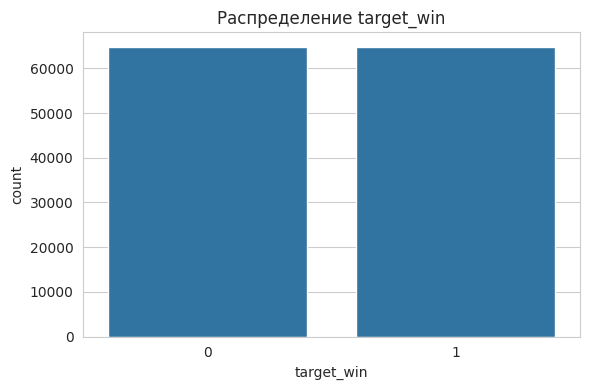

Вывод: целевая переменная имеет сбалансированную бинарную структуру на уровне команда-матч.


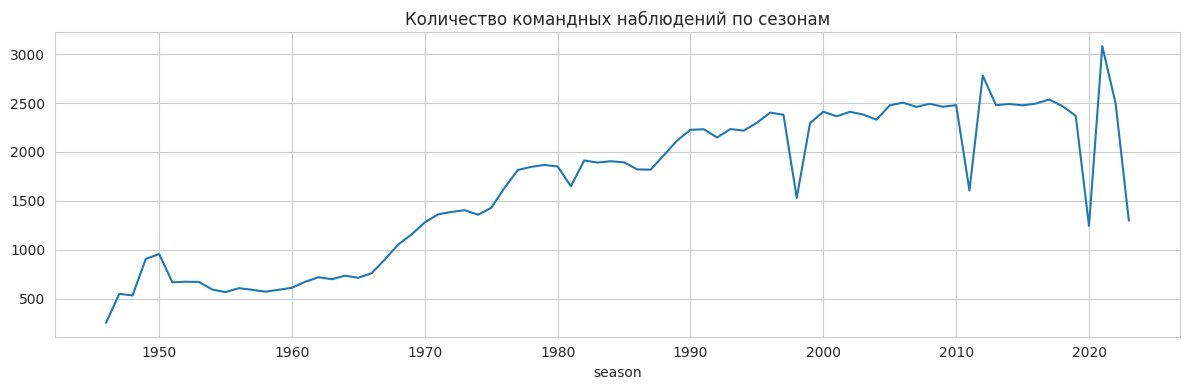

Вывод: объем наблюдений по сезонам демонстрирует устойчивое покрытие для временного моделирования.


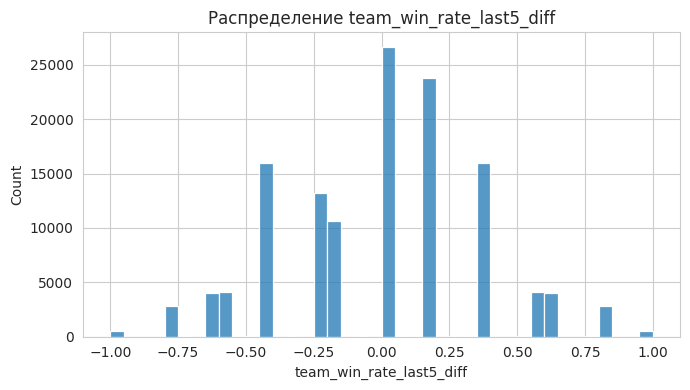

Вывод: показатель team_win_rate_last5_diff включен в модельный контур как относительный фактор матча.


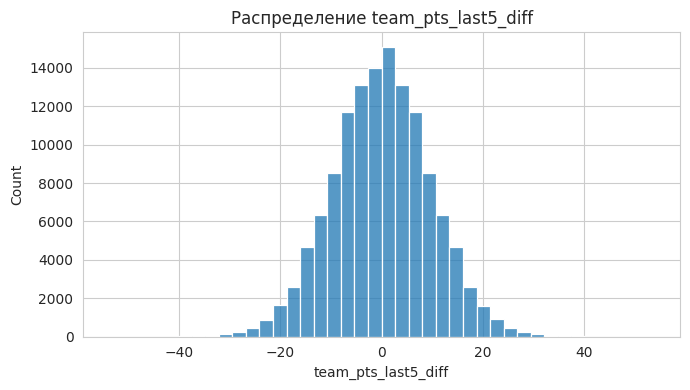

Вывод: показатель team_pts_last5_diff включен в модельный контур как относительный фактор матча.


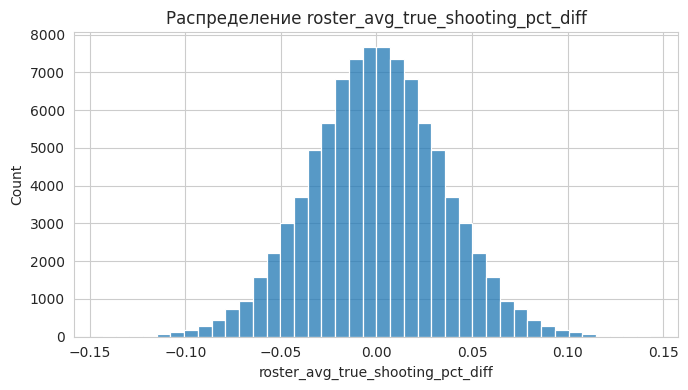

Вывод: показатель roster_avg_true_shooting_pct_diff включен в модельный контур как относительный фактор матча.


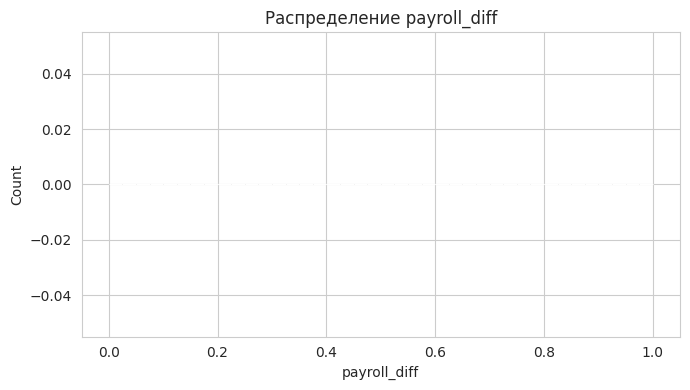

Вывод: показатель payroll_diff включен в модельный контур как относительный фактор матча.


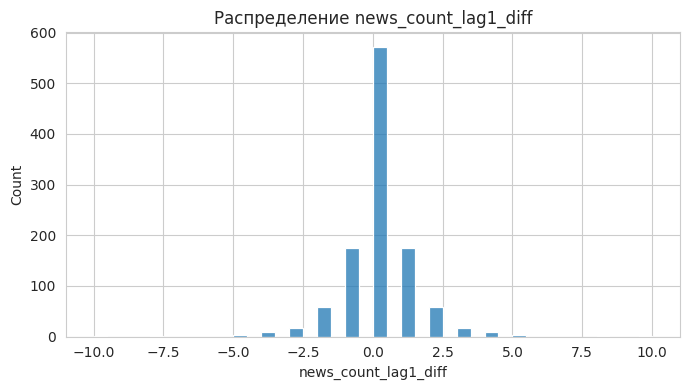

Вывод: показатель news_count_lag1_diff включен в модельный контур как относительный фактор матча.


,feature,abs_corr_with_target
0,team_win_rate_last10_diff,0.268295
1,is_home,0.241118
2,team_win_rate_last5_diff,0.215456
3,roster_total_points_diff,0.192414
4,team_win_rate_last10,0.192318
5,team_efficiency_proxy_last10_diff,0.177253
6,team_win_rate_last3_diff,0.177065
7,roster_weighted_age_by_minutes_diff,0.175556
8,roster_avg_age_diff,0.158660
9,team_win_rate_last5,0.154414


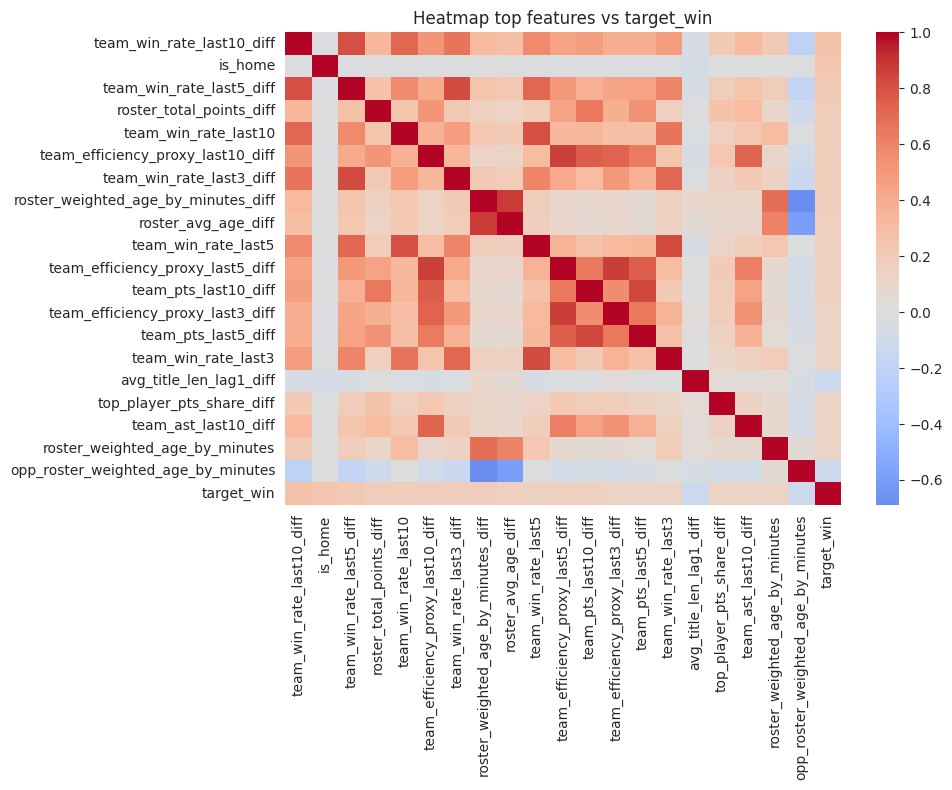

Вывод: выявлены признаки с наибольшей ассоциативной связью с целевой переменной.


,column,missing_share
0,payroll_percentile_in_season_diff,1.000000
1,salary_to_payroll_ratio_diff,1.000000
2,payroll_rank_in_season_diff,1.000000
3,payroll_diff,1.000000
4,salary_concentration_top3_diff,1.000000
5,salary_concentration_top1_diff,1.000000
6,inflation_adjusted_payroll_diff,1.000000
7,team_salary_max_diff,1.000000
8,team_salary_median_diff,1.000000
9,team_salary_mean_diff,1.000000


Вывод: пропуски локализованы преимущественно в блоках с ограниченным временным покрытием источников.


In [ ]:
# Сохранение итогового датасета
fig_dir = Path('artifacts/eda/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6,4))
sns.countplot(x='target_win', data=match_prediction_dataset)
plt.title('Распределение target_win')
plt.tight_layout(); plt.savefig(fig_dir / 'match_target_distribution.png', dpi=150); plt.show()
print('Вывод: целевая переменная имеет сбалансированную бинарную структуру на уровне команда-матч.')

plt.figure(figsize=(12,4))
match_prediction_dataset.groupby('season')['game_id'].count().plot()
plt.title('Количество командных наблюдений по сезонам')
plt.tight_layout(); plt.savefig(fig_dir / 'match_rows_by_season.png', dpi=150); plt.show()
print('Вывод: объем наблюдений по сезонам демонстрирует устойчивое покрытие для временного моделирования.')

for col, fname in [
    ('team_win_rate_last5_diff','dist_team_win_rate_last5_diff.png'),
    ('team_pts_last5_diff','dist_team_pts_last5_diff.png'),
    ('roster_avg_true_shooting_pct_diff','dist_roster_ts_diff.png'),
    ('payroll_diff','dist_payroll_diff.png'),
    ('news_count_lag1_diff','dist_news_count_lag1_diff.png'),
]:
    if col in match_prediction_dataset.columns:
        plt.figure(figsize=(7,4))
        sns.histplot(match_prediction_dataset[col], bins=40)
        plt.title(f'Распределение {col}')
        plt.tight_layout(); plt.savefig(fig_dir / fname, dpi=150); plt.show()
        print(f'Вывод: показатель {col} включен в модельный контур как относительный фактор матча.')

corr_candidates = [c for c in feature_cols_final if match_prediction_dataset[c].dtype != 'O']
if corr_candidates:
    corr_s = match_prediction_dataset[corr_candidates + ['target_win']].corr(numeric_only=True)['target_win'].drop('target_win').abs().sort_values(ascending=False)
    top_corr_cols = corr_s.head(20).index.tolist()

    corr_table = pd.DataFrame({'feature': corr_s.index, 'abs_corr_with_target': corr_s.values})
    corr_table.to_csv('artifacts/eda/tables/match_feature_target_correlations.csv', index=False)
    display(corr_table.head(20))

    heat_df = match_prediction_dataset[top_corr_cols + ['target_win']].corr(numeric_only=True)
    plt.figure(figsize=(10,8))
    sns.heatmap(heat_df, cmap='coolwarm', center=0)
    plt.title('Heatmap top features vs target_win')
    plt.tight_layout(); plt.savefig(fig_dir / 'match_top_features_heatmap.png', dpi=150); plt.show()
    print('Вывод: выявлены признаки с наибольшей ассоциативной связью с целевой переменной.')

miss_table = match_prediction_dataset.isna().mean().sort_values(ascending=False).head(30).reset_index()
miss_table.columns = ['column','missing_share']
display(miss_table)
miss_table.to_csv('artifacts/eda/tables/match_missing_top30.csv', index=False)
print('Вывод: пропуски локализованы преимущественно в блоках с ограниченным временным покрытием источников.')

## 17. Feature Sets

Раздел фиксирует формальные группы признаков для экспериментов. Разделение обеспечивает управляемость моделирования по смысловым блокам данных.

In [ ]:
# Сохранение итогового датасета
sport_form_features = [c for c in feature_cols_final if ('team_' in c and 'last' in c and not c.startswith('opp_'))]
composition_features = [c for c in feature_cols_final if c.startswith('roster_') or c in ['guards_count','forwards_count','centers_count','positional_balance_proxy']]
financial_features = [c for c in feature_cols_final if ('salary' in c.lower() or 'payroll' in c.lower()) and not c.endswith('_diff')]
news_features = [c for c in feature_cols_final if ('news_' in c.lower() or 'gdelt' in c.lower()) and not c.startswith('opp_') and not c.endswith('_diff')]
opponent_features = [c for c in feature_cols_final if c.startswith('opp_')]
diff_features = [c for c in feature_cols_final if c.endswith('_diff')]
all_model_features = sorted(set(feature_cols_final))

feature_sets = {
    'sport_form_features': sorted(sport_form_features),
    'composition_features': sorted(composition_features),
    'financial_features': sorted(financial_features),
    'news_features': sorted(news_features),
    'opponent_features': sorted(opponent_features),
    'diff_features': sorted(diff_features),
    'all_model_features': all_model_features,
}

with open('data/processed/match_prediction_feature_sets.json', 'w', encoding='utf-8') as f:
    json.dump(feature_sets, f, ensure_ascii=False, indent=2)

print('Сохранен файл data/processed/match_prediction_feature_sets.json')

Сохранен файл data/processed/match_prediction_feature_sets.json


## 18. Save Final Dataset

Раздел сохраняет итоговый модельный датасет и служебные описательные артефакты для последующих этапов экспериментов.

In [ ]:
# Сохранение итогового датасета
match_prediction_dataset.to_csv('data/processed/match_prediction_dataset.csv', index=False)
report.to_csv('data/reports/match_prediction_dataset_report.csv', index=False)

match_prediction_dataset.head(30).to_csv('data/reports/match_prediction_dataset_examples.csv', index=False)
pd.DataFrame({'column': match_prediction_dataset.columns}).to_csv('data/reports/match_prediction_dataset_columns.csv', index=False)

feature_description_rows = []
for c in match_prediction_dataset.columns:
    if c in ['game_id','game_date','season','team','opponent','is_home','target_win']:
        group = 'id_target'
    elif c.endswith('_diff'):
        group = 'diff'
    elif c.startswith('opp_'):
        group = 'opponent'
    elif 'news' in c.lower() or 'gdelt' in c.lower():
        group = 'news'
    elif 'salary' in c.lower() or 'payroll' in c.lower():
        group = 'financial'
    elif c.startswith('roster_') or c in ['guards_count','forwards_count','centers_count','positional_balance_proxy']:
        group = 'composition'
    elif 'last' in c:
        group = 'sport_form'
    else:
        group = 'other'
    feature_description_rows.append({'column': c, 'feature_group': group})

pd.DataFrame(feature_description_rows).to_csv('data/reports/match_prediction_dataset_feature_description.csv', index=False)

print('Сохранены файлы:')
print('data/processed/match_prediction_dataset.csv')
print('data/processed/match_prediction_feature_sets.json')
print('data/reports/match_prediction_dataset_report.csv')
print('data/reports/match_prediction_dataset_examples.csv')
print('data/reports/match_prediction_dataset_columns.csv')
print('data/reports/match_prediction_dataset_feature_description.csv')

Сохранены файлы:
data/processed/match_prediction_dataset.csv
data/processed/match_prediction_feature_sets.json
data/reports/match_prediction_dataset_report.csv
data/reports/match_prediction_dataset_examples.csv
data/reports/match_prediction_dataset_columns.csv
data/reports/match_prediction_dataset_feature_description.csv


## 19. Create docs/match_prediction_dataset.md

Раздел формирует текстовое описание итогового датасета в формате, пригодном для включения в исследовательскую документацию ВКР.

In [ ]:
# Сохранение итогового датасета
doc_text = """# Match Prediction Dataset

## 1. Назначение датасета
Датасет предназначен для прогнозирования результата матча NBA на уровне наблюдения «команда — матч» с бинарной целевой переменной `target_win`.

## 2. Источники данных
Использованы источники матчевой статистики игроков, сезонных характеристик игроков, зарплат, командного payroll и ежедневных новостных признаков.

## 3. Единица наблюдения
Одна строка соответствует одной команде в одном матче и определяется ключом `team, opponent, game_date, game_id`.

## 4. Целевая переменная
`target_win` принимает значение 1 в случае победы команды и 0 в случае поражения.

## 5. Логика объединения
Все источники приведены к уровню «команда — матч» через агрегации и временные преобразования, включая lag/rolling-механику.

## 6. Группы признаков
Сформированы блоки признаков: форма команды, состав, финансы, новости, признаки соперника и разностные показатели.

## 7. Признаки формы команды
Использованы rolling-метрики за окна last3/last5/last10 по игровым и результативным характеристикам команды.

## 8. Признаки состава
На уровне команда-сезон сформированы показатели возраста, минут, результативности, эффективности и структурного баланса состава.

## 9. Финансовые признаки
Сформированы агрегаты зарплат состава и признаки payroll-контекста, включая относительные показатели и внутри-сезонные ранги.

## 10. Новостные признаки
Использованы только лаговые и rolling-признаки новостного фона; признаки текущего дня в исходном виде исключены.

## 11. Признаки соперника и diff-признаки
Добавлены `opp_` признаки и разности вида «команда минус соперник» для описания относительного преимущества.

## 12. Контроль data leakage
Выполнена автоматическая проверка признаков на наличие текущих матчевых показателей; подозрительные поля исключены из итогового набора.

## 13. Ограничения датасета
Ограничения связаны с неполным покрытием отдельных исторических метрик и неоднородностью внешних источников по временной оси.

## 14. Использование на следующих этапах
Датасет предназначен для baseline-моделей, deep learning подходов и интеграции в прикладной сервис прогнозирования.
"""

Path('docs/match_prediction_dataset.md').write_text(doc_text, encoding='utf-8')
print('Создан файл docs/match_prediction_dataset.md')

Создан файл docs/match_prediction_dataset.md


## 20. Final Summary

Сформирован единый датасет `match_prediction_dataset.csv` для прогнозирования результата матча NBA на уровне «команда — матч». Все источники приведены к единому уровню объединения с включением признаков формы, состава, финансового контекста и новостного фона.

В датасет добавлены признаки соперника и разностные признаки, отражающие относительное преимущество команд. Выполнен формальный контроль data leakage: текущие матчевые показатели исключены из набора предикторов.

Итоговый набор подготовлен для последующего использования в baseline-моделях, deep learning и прикладном сервисе прогнозирования.